In [3]:
!pip install geopandas


  Using cached geopandas-1.1.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached geopandas-1.1.1-py3-none-any.whl (338 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 70.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 78.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 93.5 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 79.0 MB/s  0:00:00
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 70.5 MB/s  0:00:00
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [geopandas]/8 [geopandas]


In [4]:
import geopandas as gpd
import pandas as pd 
# Load all shapefiles into one list
files = [
    "CITY.shp",
    "RURAL.shp",
    "SVILLAGE.shp",
    "TOWN.shp",
    "VILLAGE.shp"
]

gdfs = [gpd.read_file(f) for f in files]

# Combine them into a single GeoDataFrame
all_boundaries = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

# Dissolve into one provincial boundary (union of all polygons)
alberta_boundary = all_boundaries.dissolve()

# Save to one shapefile
alberta_boundary.to_file("Alberta_boundary.shp")


In [6]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 56.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 79.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 85.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


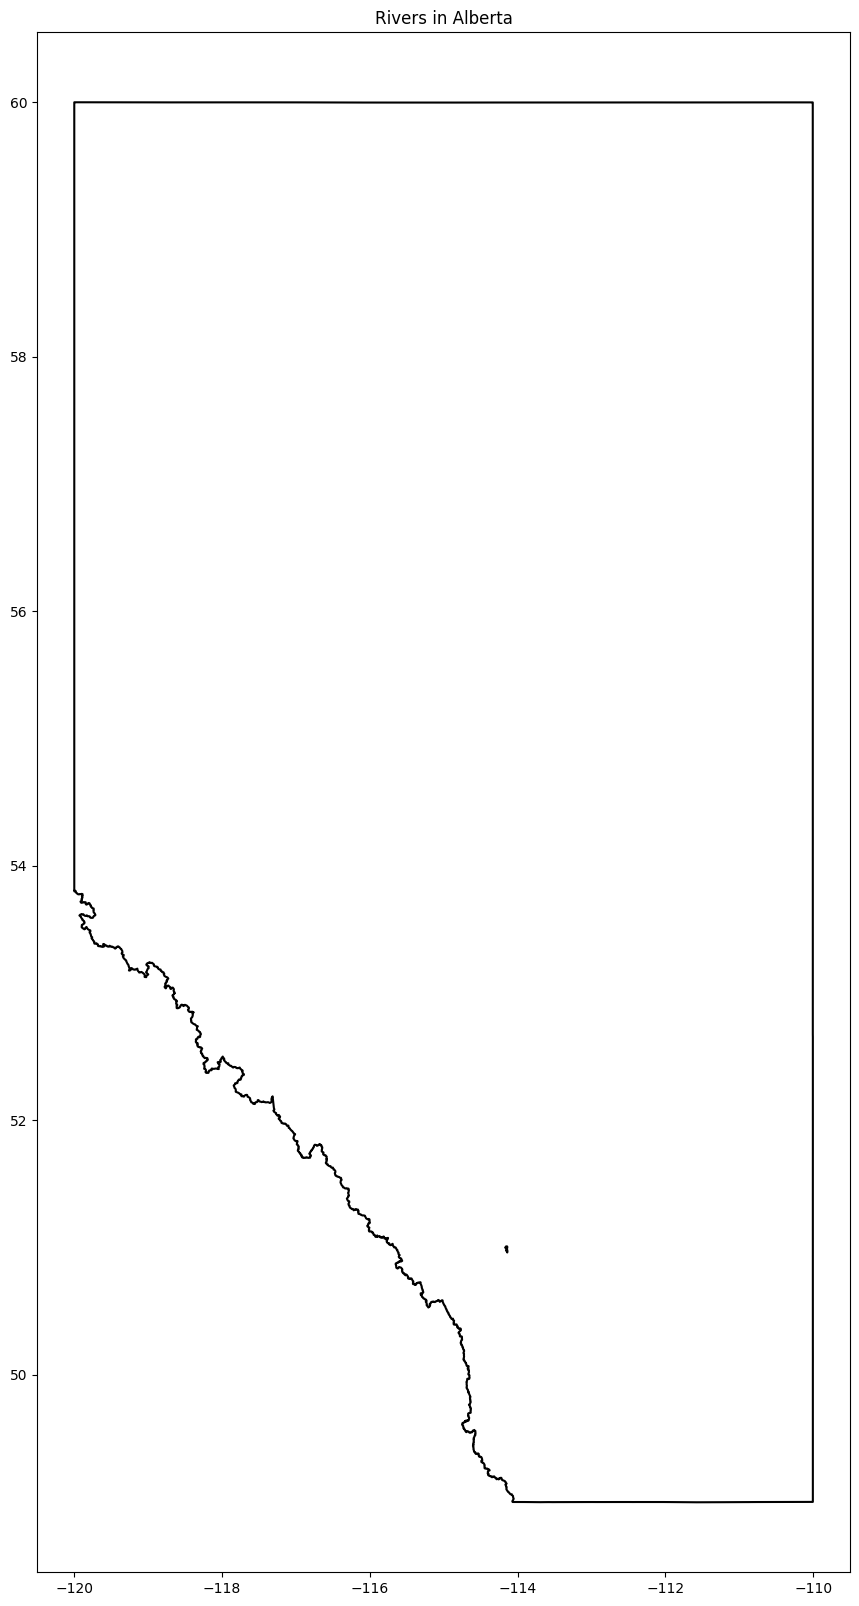

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20, 20))
alberta_boundary.boundary.plot(ax=ax, color="black")
alberta_boundary.plot(ax=ax, color="white", linewidth=0.05)
plt.title("Rivers in Alberta")
plt.show()

In [8]:
import geopandas as gpd
import pandas as pd

# List shapefiles and their "type"
files = {
    "CITY.shp"      : "City",
    "RURAL.shp"     : "Rural Municipality",
    "SVILLAGE.shp"  : "Summer village",
    "TOWN.shp"      : "Town",
    "VILLAGE.shp"   : "Village",
    "HAMLETPT.shp"  : "Hamlet point",   # <- point geometry
    "urbserv.shp"   : "Urban Service Area",
    "INDIAN.shp"    : "Indian Reserve"
}

# Create an empty geopackage path
output_gpkg = "Alberta.gpkg"

for f, ftype in files.items():
    gdf = gpd.read_file(f)
    gdf["TYPE"] = ftype   # add type column

    # Make CRS consistent (force to first loaded CRS if needed)
    if ftype != list(files.values())[0] and gdf.crs != gpd.read_file(list(files.keys())[0]).crs:
        gdf = gdf.to_crs(gpd.read_file(list(files.keys())[0]).crs)

    # Use filename (without extension) as layer name
    layer_name = "municipalities"

    # Save each dataset into its own layer in the geopackage
    gdf.to_file(output_gpkg, layer=layer_name, driver="GPKG")
